<a href="https://colab.research.google.com/github/smsag99/Thesis/blob/main/codes/dataExploring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load Animal Data


Load the dataset from '/content/drive/MyDrive/Thesis_Data/Dati_ok.txt' into a pandas DataFrame.


In [1]:
datasetAnimalPath = '/content/drive/MyDrive/Thesis_Data/Dati_ok.txt'

In [2]:
import pandas as pd

# 1. Define your column names
col_names = [
    'Farm_Code', 'Animal_ID', 'dtb', 'dtc', 'dtt',
    'parity', 'milk_kg', 'fat_p', 'protein_p', 'cells', 'NM'
]

cleaned_rows = []

# 2. Read and clean the file line by line
with open(datasetAnimalPath, 'r') as file:
    # Skip the header line
    next(file)

    for line in file:
        # Remove whitespace/newlines from ends
        line = line.strip()

        # Skip empty lines if any exist
        if not line:
            continue

        # Split the line by comma
        parts = line.split(',')

        # LOGIC: Fix the rows based on length
        if len(parts) == 11:
            # This is a correct row, keep it as is
            cleaned_rows.append(parts)

        elif len(parts) == 12:
            # This is a broken row.
            # This leaves one empty slot for 'dtb' and shifts the rest back.
            parts.pop(2)
            cleaned_rows.append(parts)

# 3. Create the DataFrame
df_animal = pd.DataFrame(cleaned_rows, columns=col_names)

# 4. Convert columns to correct types (since they were read as strings)
numeric_cols = ['Farm_Code','parity', 'milk_kg', 'fat_p', 'protein_p', 'cells', 'NM']
for col in numeric_cols:
    df_animal[col] = pd.to_numeric(df_animal[col], errors='coerce')

# 5. Convert Date Columns
date_cols = ['dtb', 'dtc', 'dtt']
for col in date_cols:
    df_animal[col] = pd.to_datetime(df_animal[col], format='%Y%m%d', errors='coerce')

# Check the result
print(df_animal.head(20))
print(f"\nTotal rows loaded: {len(df_animal)}")

    Farm_Code       Animal_ID        dtb        dtc        dtt  parity  \
0      521513  IT003990094624 2013-10-29 2022-06-07 2022-06-20       6   
1      521513  IT003990094624 2013-10-29 2022-06-07 2022-07-19       6   
2      521513  IT003990094624 2013-10-29 2022-06-07 2022-09-12       6   
3      521513  IT003990094624 2013-10-29 2022-06-07 2022-10-13       6   
4      521513  IT003990094624 2013-10-29 2022-06-07 2022-11-15       6   
5      521513  IT003990057639 2009-12-09 2013-05-27 2013-06-04       1   
6      521513  IT003990057639 2009-12-09 2013-05-27 2013-07-02       1   
7      521513  IT003990057639 2009-12-09 2013-05-27 2013-09-03       1   
8      521513  IT003990057639 2009-12-09 2013-05-27 2013-10-02       1   
9      521513  IT003990057639 2009-12-09 2013-05-27 2013-11-04       1   
10     521513  IT003990057639 2009-12-09 2013-05-27 2013-12-02       1   
11     521513  IT003990065238 2011-04-13 2021-08-25 2021-09-06       3   
12     521513  IT003990065238 2011-04-

In [3]:
df_animal.isnull().sum()

,0
Farm_Code,0
Animal_ID,0
dtb,1873
dtc,0
dtt,0
parity,0
milk_kg,0
fat_p,0
protein_p,0
cells,0


In [4]:
print("Descriptive statistics for numerical columns:")
df_animal.describe()

Descriptive statistics for numerical columns:


,Farm_Code,dtb,dtc,dtt,parity,milk_kg,fat_p,protein_p,cells,NM
count,2.593267e+06,2591394,2593267,2593267,2.593267e+06,2.593267e+06,2.593267e+06,2.593267e+06,2.593267e+06,2.593267e+06
mean,6.239304e+06,2013-01-15 01:02:46.180518656,2019-02-12 07:56:07.435903232,2019-07-08 02:21:46.675169536,3.379940e+00,9.043340e+01,7.788952e+02,4.567361e+02,2.811822e+02,1.973870e+00
min,5.215130e+05,1985-07-01 00:00:00,2011-05-09 00:00:00,2013-01-02 00:00:00,1.000000e+00,0.000000e+00,-3.870000e+02,-2.370000e+02,0.000000e+00,1.000000e+00
25%,5.700749e+06,2010-01-23 00:00:00,2016-05-11 00:00:00,2016-10-11 00:00:00,1.000000e+00,6.500000e+01,6.720000e+02,4.390000e+02,4.300000e+01,2.000000e+00
50%,6.800300e+06,2013-03-13 00:00:00,2019-11-02 00:00:00,2020-03-09 00:00:00,3.000000e+00,8.700000e+01,7.960000e+02,4.670000e+02,9.600000e+01,2.000000e+00
75%,7.000160e+06,2016-07-06 00:00:00,2021-11-25 00:00:00,2022-04-04 00:00:00,5.000000e+00,1.140000e+02,9.150000e+02,4.980000e+02,2.390000e+02,2.000000e+00
max,9.410250e+06,2021-12-29 00:00:00,2023-12-24 00:00:00,2023-12-29 00:00:00,2.700000e+01,8.860000e+02,7.943000e+03,8.557000e+03,9.814700e+04,3.000000e+00
std,1.538862e+06,NaN,NaN,NaN,2.437515e+00,3.808888e+01,2.387913e+02,9.352945e+01,7.981789e+02,1.717433e-01


### Parameters Analysis

Generating data visualizations for numerical columns...


NameError: name 'df' is not defined

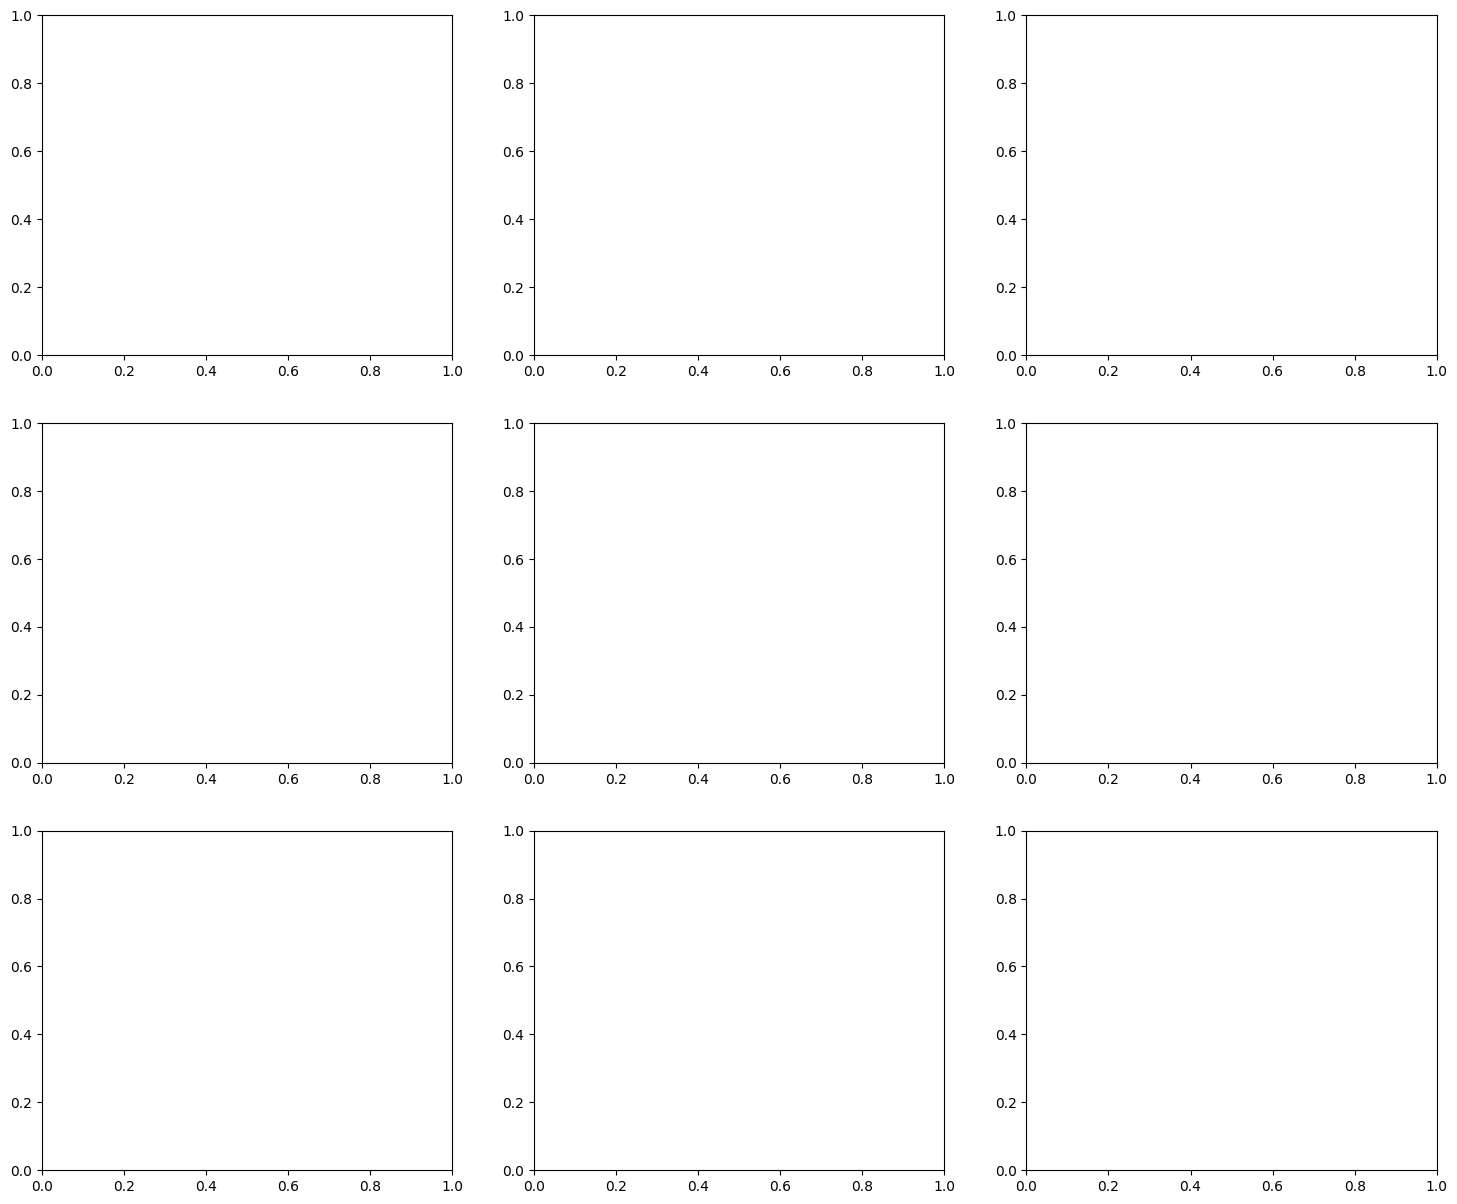

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating data visualizations for numerical columns...")

# Set up the matplotlib figure and axes for subplots
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten() # Flatten the 3x3 array of axes for easy iteration

# Select numerical columns for visualization, excluding date-like integers and IDs
numerical_cols = ['parity', 'milk_kg', 'fat_p', 'protein_p', 'cells', 'NM']

# Create histograms for numerical columns
for i, col in enumerate(numerical_cols):
    if i < len(axes):
        sns.histplot(df[col], kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### parity

In [ ]:
df['parity'].quantile([0.01,0.99])

In [ ]:
len(df[(df['parity'] > 11) | (df['parity'] < 1)])

#### milk_kg

In [ ]:
df['milk_kg'].quantile([0.01,0.99])

In [ ]:
len(df[(df['milk_kg'] > 193) | (df['milk_kg'] < 18)])

#### fat_p


In [ ]:
len(df[df['fat_p']==0])

In [ ]:
df['fat_p'].quantile([0.03,0.99])

In [ ]:
len(df[(df['fat_p'] > 1327) | (df['fat_p'] < 36)])

#### protein_p

In [ ]:
len(df[df['protein_p']==0])

In [ ]:
df['protein_p'].quantile([0.03,0.99])

In [ ]:
len(df[(df['protein_p'] > 588) | (df['protein_p'] < 63)])

#### cells

In [ ]:
len(df[df['cells']==0])

In [ ]:
df['cells'].quantile([0.05,0.99])

In [ ]:
len(df[(df['cells'] > 3081) | (df['cells'] < 4)])

#### NM

In [ ]:
df['NM'].quantile([0.01,0.99])

In [ ]:
len(df[(df['NM'] > 2) | (df['NM'] < 1)])

## Load Farm Data

In [1]:
datasetFarmPath = '/content/drive/MyDrive/Thesis_Data/latitude and longitude.xlsx'

In [2]:
import pandas as pd

# 1. Define your column names (assuming Excel has headers, these will be used for verification)
col_names = [
    'Farm_name','Commercial_name','Farm_code','ASL_code','Adress','City','Postal_code','Province','Region','Latitude','Longitude'
]

# 2. Read the Excel file into a DataFrame
df_farm = pd.read_excel(datasetFarmPath)

# Check the result
print(df_farm.head())
print(f"\nTotal rows loaded: {len(df_farm)}")

                 Farm name                       Commercial name  Farm_code  \
0  ABBATE MARIA ANTONIETTA               ABBATE MARIA ANTONIETTA    6811505   
1          BOTTAI LEONARDO  AGRIAMBIENTE MUGELLO SOC. COOP. AGR.    4241329   
2          DIANA VALENTINA              AGRICOLA DIANA VALENTINA    6811588   
3         GIULIANI ALVIDIO             AGRICOLA GIULIANI ALVIDIO    5600136   
4              RUBINO VITO    AGRICOLA LA PESCARA DI VITO RUBINO    6812804   

   ASL_code                                 Adress                      City  \
0  084CE077                          VIA NAZIONALE  SANTA MARIA CAPUA VETERE   
1  004FI004                   VIA DI GALLIANO 15/A      BARBERINO DI MUGELLO   
2  027CE147                     P.CO SAN BENEDETTO           CASTEL VOLTURNO   
3  005FR138                    VIA COLLE COTTO. 37                   AMASENO   
4  068CE017  Via Santa Lucia 3 Loc. Pietre Bianche                    RIARDO   

   Postal_code Province    Region   Latitude

In [3]:
df_farm.loc[164,'Province'] = 'CA'

### Farms on the Map

In [10]:
import folium

# Calculate the mean latitude and longitude to center the map
mean_lat = df_farm['Latitude'].mean()
mean_lon = df_farm['Longitude'].mean()

# Create a base map centered around the mean coordinates
m = folium.Map(location=[mean_lat, mean_lon], zoom_start=6)

# Add a marker for each farm
for index, row in df_farm.iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=f"<b>Farm:</b> {row['Farm name']}<br><b>Code:</b> {row['Farm_code']}",
        tooltip=row['Farm name']
    ).add_to(m)

# Display the map
m

## Trying to use Meteo API



In [4]:
!pip install openmeteo-requests
!pip install requests-cache retry-requests numpy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 685.7/685.7 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.8/138.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.1/394.1 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 23.5 MB/s eta 0:00:00
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 25.12.19
    Uninstalling flatbuffers-25.12.19:
      Successfully uninstalled flatbuffers-25.12.19
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 4.3 MB/s eta 0:00:00


In [5]:
farm_loc = df_farm[['Farm_code', 'Latitude', 'Longitude']].copy()
print(farm_loc.head())

   Farm_code   Latitude  Longitude
0    6811505  41.081755  14.266145
1    4241329  44.014669  11.291554
2    6811588  41.057681  13.919402
3    5600136  41.466164  13.330085
4    6812804  41.263069  14.151205


In [ ]:
# Select relevant columns from df_animal
df_animal_selected = df_animal[['Farm_Code', 'dtt']]

# Select relevant columns from df_farm
df_farm_selected = df_farm[['Farm_code', 'Latitude', 'Longitude']]

# Merge the two selected DataFrames on 'Farm_code'
df_merged = pd.merge(
    df_animal_selected,
    df_farm_selected,
    left_on='Farm_Code',
    right_on='Farm_code',
    how='inner'  # Use an inner merge to keep only matching Farm_codes
)

# Drop the redundant 'Farm_code' column from df_farm_selected after merge if needed,
# or simply rename one of them if there's a conflict.
# For now, let's assume 'Farm_Code' from df_animal_selected is kept as the primary.
df_merged = df_merged.drop(columns=['Farm_code'])

print("Head of df_merged:")
print(df_merged.head())
print(f"\nTotal rows in df_merged: {len(df_merged)}")

# Task
Create a directory named "farm_weather_data" and, for each unique farm in the `farm_loc` DataFrame, fetch hourly temperature and relative humidity data from the Open-Meteo Archive API for the period "2013-01-01" to "2025-12-31", then save this data as a separate CSV file named "farm_<Farm_code>_weather.csv" within the "farm_weather_data" directory.

## Define Output Directory

### Subtask:
Create a directory to store the downloaded CSV files for each farm's weather data.


**Reasoning**:
I need to import the 'os' module, define the output directory name, and then create the directory using 'os.makedirs' as instructed.



In [8]:
import os

# Define the output directory name
output_directory = "drive/MyDrive/Thesis_Data/farm_weather_data"

# Create the directory if it doesn't already exist
os.makedirs(output_directory, exist_ok=True)

print(f"Directory '{output_directory}' ensured to exist.")

Directory 'drive/MyDrive/Thesis_Data/farm_weather_data' ensured to exist.


**Reasoning**:
The subtask of creating the directory is complete. The next step is to iterate through each unique farm in `farm_loc`, fetch the specified hourly weather data from the Open-Meteo API, and save it to individual CSV files within the created directory. This will involve setting up the API call with the correct parameters for hourly data and implementing retry logic with delays to handle potential rate limits.



In [17]:
!ls drive/MyDrive/Thesis_Data/farm_weather_data/ -al

total 1536211
-rw------- 1 root root 4715604 Feb 17 17:30 farm_1114232.0_weather.csv
-rw------- 1 root root 4719420 Feb 17 17:22 farm_1126225.0_weather.csv
-rw------- 1 root root 4677825 Feb 17 17:32 farm_1333106.0_weather.csv
-rw------- 1 root root 4712860 Feb 17 17:27 farm_2212414.0_weather.csv
-rw------- 1 root root 4727528 Feb 17 17:27 farm_2212415.0_weather.csv
-rw------- 1 root root 4684354 Feb 17 17:29 farm_2245202.0_weather.csv
-rw------- 1 root root 4720168 Feb 17 17:30 farm_2541309.0_weather.csv
-rw------- 1 root root 4868100 Feb 17 17:29 farm_2750207.0_weather.csv
-rw------- 1 root root 4862991 Feb 17 17:05 farm_2750230.0_weather.csv
-rw------- 1 root root 4724086 Feb 17 17:31 farm_3621143.0_weather.csv
-rw------- 1 root root 4656129 Feb 17 17:16 farm_4146101.0_weather.csv
-rw------- 1 root root 4637958 Feb 17 17:05 farm_4241329.0_weather.csv
-rw------- 1 root root 4690758 Feb 17 17:34 farm_4320122.0_weather.csv
-rw------- 1 root root 4705798 Feb 17 17:16 farm_5010267.0_weat

In [16]:
import openmeteo_requests
import requests_cache
from retry_requests import retry
import pandas as pd
import time
import os

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# Define the API URL for historical weather data
url = "https://archive-api.open-meteo.com/v1/archive"

# Define the output directory (already created in the previous step)
output_directory = "drive/MyDrive/Thesis_Data/farm_weather_data"

# Define the common date range for all farms
common_start_date = "2013-01-01"
common_end_date = "2025-12-31"

print(f"Fetching hourly weather data for {len(farm_loc)} unique farms...")

for index, row in farm_loc.iterrows():
    farm_code = row['Farm_code']
    latitude = row['Latitude']
    longitude = row['Longitude']

    # Define the output file path
    output_file_path = os.path.join(output_directory, f"farm_{farm_code}_weather.csv")

    # Check if the CSV file already exists for this farm
    if os.path.exists(output_file_path):
        print(f"Skipping Farm Code {farm_code}: CSV file already exists at {output_file_path}")
        continue # Skip to the next farm

    # Parameters for hourly data as per task requirement
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": common_start_date,
        "end_date": common_end_date,
        "hourly": ["temperature_2m", "relative_humidity_2m"], # Hourly data requested
        "timezone": "auto"
    }

    try:
        responses = openmeteo.weather_api(url, params=params)

        # Process first location
        response = responses[0]

        # Process hourly data
        hourly = response.Hourly()
        hourly_data = {
            "time": pd.date_range(
            start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
            end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
            freq = pd.Timedelta(seconds = hourly.Interval()),
            inclusive = "left"
            ),
            "temperature_2m": hourly.Variables(0).ValuesAsNumpy(),
            "relative_humidity_2m": hourly.Variables(1).ValuesAsNumpy()
        }


        current_weather_df = pd.DataFrame(hourly_data)

        # Save the DataFrame to a CSV file
        current_weather_df.to_csv(output_file_path, index=False)
        print(f"Successfully fetched and saved data for Farm Code {farm_code} to {output_file_path}")

    except Exception as e:
        print(f"Error fetching data for Farm Code {farm_code} (Lat: {latitude}, Lon: {longitude}): {e}")

    # Add a small delay to avoid hitting rate limits. Increasing from 1s to 5s due to previous API errors.
    time.sleep(0) # Wait for 5 seconds between requests

print("Finished processing all farms.")

Fetching hourly weather data for 329 unique farms...
Skipping Farm Code 6811505.0: CSV file already exists at drive/MyDrive/Thesis_Data/farm_weather_data/farm_6811505.0_weather.csv
Skipping Farm Code 4241329.0: CSV file already exists at drive/MyDrive/Thesis_Data/farm_weather_data/farm_4241329.0_weather.csv
Skipping Farm Code 6811588.0: CSV file already exists at drive/MyDrive/Thesis_Data/farm_weather_data/farm_6811588.0_weather.csv
Skipping Farm Code 5600136.0: CSV file already exists at drive/MyDrive/Thesis_Data/farm_weather_data/farm_5600136.0_weather.csv
Skipping Farm Code 6812804.0: CSV file already exists at drive/MyDrive/Thesis_Data/farm_weather_data/farm_6812804.0_weather.csv
Skipping Farm Code 5744453.0: CSV file already exists at drive/MyDrive/Thesis_Data/farm_weather_data/farm_5744453.0_weather.csv
Skipping Farm Code 6811569.0: CSV file already exists at drive/MyDrive/Thesis_Data/farm_weather_data/farm_6811569.0_weather.csv
Skipping Farm Code 6811565.0: CSV file already exis